# Logistic regression

## Imports

After the baseline, I decided to try two simple models: logistic regression and decision tree. I want to compare these two approaches and then, if necessary, move on to a more complex models.

In [1]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

from heart_failure.modeling.train import optuna_search_lr
from heart_failure.config.modeling import CV_SPLITS, LR_N_TRIALS, LR_SCORING, F_BETA_THRESHOLD
from heart_failure.config.config import INTERIM_DATA_DIR, HEART_DISEASE, SEX, PROCESSED_DATA_DIR
from heart_failure.config.features import TEST_SIZE, RANDOM_STATE, VAL_SIZE
from heart_failure.reports import print_best_params
from heart_failure.modeling.evaluate import (
    get_metrics, log_metrics, optuna_cv_results_to_df, find_best_threshold
)
from heart_failure.modeling.predict import predict_by_threshold

2026-06-16 17:08:36.849 | INFO     | heart_failure.config.config:<module>:11 - PROJ_ROOT path is: D:\heart_failure


In [2]:
MODEL_NAME = "logistic_regression"
mlflow.set_experiment(f"heart_failure")

<Experiment: artifact_location='file:D:/heart_failure/notebooks/mlruns/1', creation_time=1781534399229, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781534399229, lifecycle_stage='active', name='heart_failure', tags={}, trace_location=None, workspace='default'>

In [46]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")
rem_columns = pd.read_csv(PROCESSED_DATA_DIR / "remaining_cols.csv")
rem_columns = rem_columns.squeeze().to_list()

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

stratify = df[[SEX, HEART_DISEASE]]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=stratify
)
val_stratify = [X_train[SEX], y_train]
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=y_train
)

## Training

In [ ]:
study, model = optuna_search_lr(
    X_train,
    y_train,
    n_trials=LR_N_TRIALS,
    n_splits=CV_SPLITS,
    scoring=LR_SCORING,
    rem_columns=rem_columns,
    random_state=RANDOM_STATE,
)

In [48]:
print_best_params(study)

Best parameters: {'model__solver': 'lbfgs', 'model__C': 0.12016987629425627, 'model__max_iter': 193, 'model__tol': 5.631418020701252e-05}
Best score: 0.94185


In [49]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
42,"{'model__solver': 'lbfgs', 'model__C': 0.12016...",0.012808,0.941847,0.953844,0.935926,0.934262,0.959668,0.925534,1
36,"{'model__solver': 'lbfgs', 'model__C': 0.11349...",0.013036,0.941815,0.953934,0.936082,0.934262,0.959896,0.924903,2
7,"{'model__solver': 'lbfgs', 'model__C': 0.13687...",0.012857,0.941560,0.953707,0.935765,0.933674,0.959387,0.925268,3
32,"{'model__solver': 'lbfgs', 'model__C': 0.03459...",0.012437,0.941482,0.951582,0.936131,0.934431,0.959814,0.925453,4
27,"{'model__solver': 'lbfgs', 'model__C': 0.04683...",0.012434,0.941480,0.952550,0.936411,0.933599,0.959167,0.925675,5


The scores for different trials are very similar. Hyperparameters don't have that much of an impact on the results in this case. So, we're limited by the informativeness of the features.

In [50]:
lr = model.named_steps["model"]
weights = pd.Series(lr.coef_.ravel(), index=rem_columns)
weights.sort_values(key=abs, ascending=False)

target_encoder__ST_Slope          0.716222
remainder__conjunctive_rules      0.629261
target_encoder__ChestPainType     0.600910
binary_encoder__Sex               0.515349
binary_encoder__FastingBS         0.350078
remainder__Oldpeak                0.251277
binary_encoder__ExerciseAngina    0.243806
binarizer__Cholesterol            0.181991
binarizer__Age                    0.098223
remainder__MaxHR_z               -0.084257
binarizer__MaxHR                 -0.063327
dtype: float64

The model barely considers MaxHR. ST_Slope is perceived as the best feature, followed by conjunctive_rules. These two features are quite correlated (~0.75). What happens if we remove one of these features entirely?

Perhaps Age, Oldpeak, and MaxHR are ranked lower due to information duplication in the conjunctive_rules (and ST_Slope).

### Threshold searching

In [69]:
y_val_proba = model.predict_proba(X_val)[:, 1]
best_threshold = find_best_threshold(y_val, y_val_proba, F_BETA_THRESHOLD)
best_threshold

np.float64(0.449)

The value 1.1 was chosen as beta, since at higher values the threshold drops too low, and class 0 is not predicted at all.

## Metrics

In [70]:
print("Train metrics")
y_train_pred = predict_by_threshold(model, X_train, best_threshold)
y_train_proba = model.predict_proba(X_train)[:, 1]
train_metrics = get_metrics(y_train, y_train_pred, y_train_proba)
train_metrics

Train metrics


precision    0.870370
recall       0.903846
f2_score     0.896947
pr_auc       0.946276
dtype: float64

The metrics are slightly better than the baseline. It's possible that conjunctive_rules currently covers a larger class area, causing some remaining dependencies to be nonlinear, and logistic regression can't detect them.

In [71]:
print("Test metrics")
y_test_pred = predict_by_threshold(model, X_test, best_threshold)
y_test_proba = model.predict_proba(X_test)[:, 1]
test_metrics = get_metrics(y_test, y_test_pred, y_test_proba)
test_metrics

Test metrics


precision    0.834783
recall       0.941176
f2_score     0.917782
pr_auc       0.908164
dtype: float64

On the test, the metrics are also better compared to the baseline, but the precision drops compared to the train set.

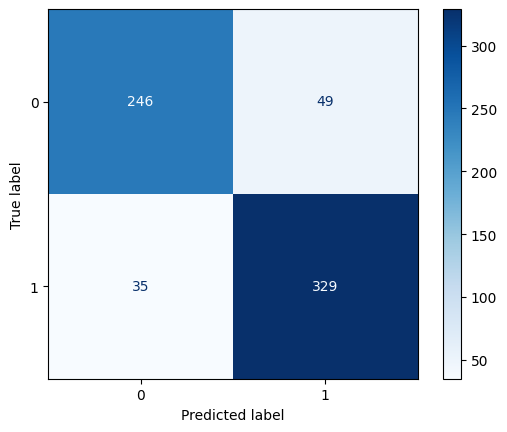

In [72]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, cmap="Blues")
plt.show()

In this case, FP, FN practically the same as for the baseline.

In [75]:
with mlflow.start_run(run_name=MODEL_NAME) as run:
    mlflow.log_param("model", MODEL_NAME)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("cv_splits", CV_SPLITS)
    mlflow.log_param("optuna_n_trials", LR_N_TRIALS)
    mlflow.log_param("remaining_columns", rem_columns)
    mlflow.log_param("f_beta_threshold", F_BETA_THRESHOLD)
    mlflow.log_param("proba_threshold", best_threshold)

    log_metrics(train_metrics, "train_")
    log_metrics(test_metrics, "test_")